# 03 — Emotion Manipulation Check

This notebook evaluates whether the experimental emotion-induction
procedures produced the intended changes in participants' emotional state.

## Objectives

1. Describe SAM measurements across experimental timepoints.
2. Evaluate within-session changes in emotional state.
3. Compare positive and negative emotion-induction conditions.
4. Evaluate pre-post changes in State scores.
5. Examine the persistence of emotional induction across the session.
6. Assess whether the manipulation was successful before testing its
   effects on working-memory performance.

This notebook focuses exclusively on manipulation checks.

Working-memory outcomes are not used for confirmatory hypothesis testing here.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src import config as cfg

from src.utils import (
    initialize_project,
)

from src.visualization import (
    stat_within,
    stat_between,
    stat_histogram,
)

initialize_project()

In [2]:
from src.visualization import (
    stat_sam_trajectory,
)

In [3]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

print(
    f"Trials: {len(analysis):,}"
)

print(
    "Participants:",
    analysis["participant_id"].nunique(),
)

Trials: 17,820
Participants: 23


In [4]:
participant_data = (
    analysis
    .sort_values(
        [
            "participant_id",
            "session_number",
        ]
    )
    .groupby(
        "participant_id",
        as_index=False,
    )
    .first()
)

print(
    "Participant-level N:",
    len(participant_data),
)

Participant-level N: 23


In [5]:
sam_columns = [
    column
    for column in participant_data.columns
    if column.startswith("sam_")
]

sam_columns

['sam_neg_v1_mean',
 'sam_neg_v2_mean',
 'sam_neg_v3_mean',
 'sam_neg_v3_1_mean',
 'sam_neg_v3_2_mean',
 'sam_neg_v4_mean',
 'sam_neg_v5_mean',
 'sam_neg_v6_mean',
 'sam_neg_v6_3_mean',
 'sam_neg_v6_4_mean',
 'sam_neg_v7_mean',
 'sam_pos_v1_mean',
 'sam_pos_v2_mean',
 'sam_pos_v3_mean',
 'sam_pos_v3_1_mean',
 'sam_pos_v3_2_mean',
 'sam_pos_v4_mean',
 'sam_pos_v5_mean',
 'sam_pos_v6_mean',
 'sam_pos_v6_3_mean',
 'sam_pos_v6_4_mean',
 'sam_pos_v7_mean']

In [6]:
participant_data[
    sam_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
sam_neg_v1_mean,23.0,5.782609,1.881888,1.0,5.0,6.0,7.0,9.0
sam_neg_v2_mean,23.0,4.826087,1.874522,1.0,4.0,5.0,6.5,8.0
sam_neg_v3_mean,23.0,3.478261,1.473079,1.0,2.5,4.0,4.0,7.0
sam_neg_v3_1_mean,23.0,4.130435,1.984127,1.0,3.0,4.0,5.0,9.0
sam_neg_v3_2_mean,23.0,5.130435,2.321918,1.0,3.5,5.0,7.0,9.0
sam_neg_v4_mean,23.0,4.130435,1.816699,1.0,3.0,4.0,4.5,9.0
sam_neg_v5_mean,22.0,5.954545,1.587969,3.0,5.0,6.0,7.0,9.0
sam_neg_v6_mean,23.0,3.130435,1.516705,1.0,2.0,3.0,4.0,6.0
sam_neg_v6_3_mean,23.0,4.434783,1.700965,2.0,3.0,4.0,5.0,8.0
sam_neg_v6_4_mean,23.0,4.826087,2.208500,1.0,3.5,5.0,6.5,9.0


In [7]:
sam_missing = (
    participant_data[
        sam_columns
    ]
    .isna()
    .sum()
    .to_frame(
        "missing"
    )
)

sam_missing[
    "percent"
] = (
    sam_missing["missing"]
    / len(participant_data)
    * 100
)

sam_missing

,missing,percent
sam_neg_v1_mean,0,0.000000
sam_neg_v2_mean,0,0.000000
sam_neg_v3_mean,0,0.000000
sam_neg_v3_1_mean,0,0.000000
sam_neg_v3_2_mean,0,0.000000
sam_neg_v4_mean,0,0.000000
sam_neg_v5_mean,1,4.347826
sam_neg_v6_mean,0,0.000000
sam_neg_v6_3_mean,0,0.000000
sam_neg_v6_4_mean,0,0.000000


In [8]:
from src.preprocessing import (
    reshape_sam_long,
)

sam_long = reshape_sam_long(
    participant_data
)

sam_long.head(20)

,participant_id,sam_variable,sam_score,emotion,timepoint
0,1101,sam_neg_v1_mean,6.0,Negative,1
1,1106,sam_neg_v1_mean,5.0,Negative,1
2,1107,sam_neg_v1_mean,6.0,Negative,1
3,1108,sam_neg_v1_mean,5.0,Negative,1
4,1122,sam_neg_v1_mean,9.0,Negative,1
5,1123,sam_neg_v1_mean,4.0,Negative,1
6,1126,sam_neg_v1_mean,7.0,Negative,1
7,1128,sam_neg_v1_mean,8.0,Negative,1
8,1135,sam_neg_v1_mean,7.0,Negative,1
9,1150,sam_neg_v1_mean,5.0,Negative,1


In [9]:
sam_long.groupby(
    [
        "emotion",
        "timepoint",
    ]
).size()

emotion   timepoint
Negative  1            23
          2            23
          3            23
          3_1          23
          3_2          23
          4            23
          5            23
          6            23
          6_3          23
          6_4          23
          7            23
Positive  1            23
          2            23
          3            23
          3_1          23
          3_2          23
          4            23
          5            23
          6            23
          6_3          23
          6_4          23
          7            23
dtype: int64

In [10]:
sam_long[
    "timepoint"
].value_counts()

timepoint
1      46
2      46
3      46
3_1    46
3_2    46
4      46
5      46
6      46
6_3    46
6_4    46
7      46
Name: count, dtype: int64

In [11]:
sam_summary = (
    sam_long
    .groupby(
        [
            "emotion",
            "timepoint",
        ],
        dropna=False,
    )
    .agg(
        n=(
            "sam_score",
            "count",
        ),
        mean=(
            "sam_score",
            "mean",
        ),
        sd=(
            "sam_score",
            "std",
        ),
        median=(
            "sam_score",
            "median",
        ),
        minimum=(
            "sam_score",
            "min",
        ),
        maximum=(
            "sam_score",
            "max",
        ),
    )
    .reset_index()
)

sam_summary

,emotion,timepoint,n,mean,sd,median,minimum,maximum
0,Negative,1,23,5.782609,1.881888,6.0,1.0,9.0
1,Negative,2,23,4.826087,1.874522,5.0,1.0,8.0
2,Negative,3,23,3.478261,1.473079,4.0,1.0,7.0
3,Negative,3_1,23,4.130435,1.984127,4.0,1.0,9.0
4,Negative,3_2,23,5.130435,2.321918,5.0,1.0,9.0
5,Negative,4,23,4.130435,1.816699,4.0,1.0,9.0
6,Negative,5,22,5.954545,1.587969,6.0,3.0,9.0
7,Negative,6,23,3.130435,1.516705,3.0,1.0,6.0
8,Negative,6_3,23,4.434783,1.700965,4.0,2.0,8.0
9,Negative,6_4,23,4.826087,2.208500,5.0,1.0,9.0


In [12]:
sam_plot_data = (
    sam_long
    .groupby(
        [
            "emotion",
            "timepoint",
        ]
    )
    ["sam_score"]
    .mean()
    .reset_index()
)

In [13]:
timepoint_order = [
    value
    for value in cfg.SAM_TIMEPOINT_ORDER
    if value in set(
        sam_long["timepoint"]
    )
]

In [14]:
sam_plot_data[
    "timepoint"
] = pd.Categorical(
    sam_plot_data[
        "timepoint"
    ],
    categories=timepoint_order,
    ordered=True,
)

sam_plot_data = (
    sam_plot_data
    .sort_values(
        "timepoint"
    )
)

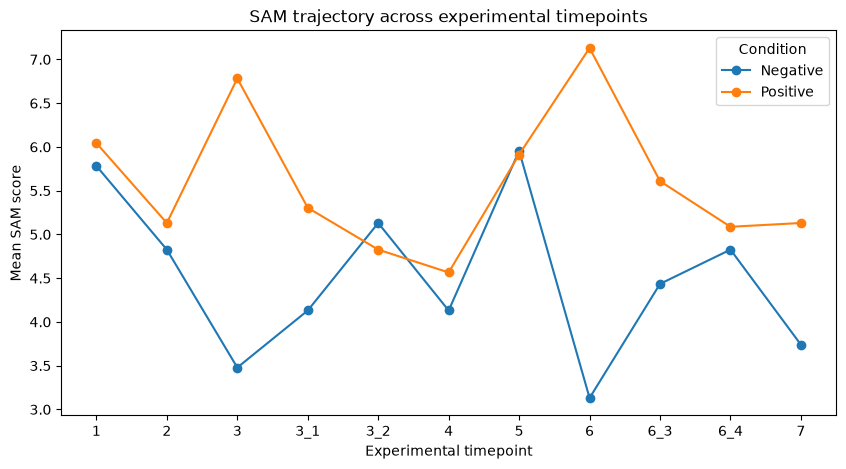

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for emotion, group in (
    sam_plot_data.groupby(
        "emotion"
    )
):

    ax.plot(
        group[
            "timepoint"
        ].astype(str),
        group[
            "sam_score"
        ],
        marker="o",
        label=emotion,
    )

ax.set_xlabel(
    "Experimental timepoint"
)

ax.set_ylabel(
    "Mean SAM score"
)

ax.set_title(
    "SAM trajectory across experimental timepoints"
)

ax.legend(
    title="Condition"
)

plt.show()

In [16]:
sam_pre_post_1 = (
    sam_long[
        sam_long[
            "timepoint"
        ].isin(
            ["2", "3"]
        )
    ]
    .copy()
)

In [17]:
sam_change_1 = (
    sam_pre_post_1
    .pivot_table(
        index=[
            "participant_id",
            "emotion",
        ],
        columns="timepoint",
        values="sam_score",
        aggfunc="first",
    )
    .reset_index()
)

In [18]:
sam_change_1[
    "change"
] = (
    sam_change_1["3"]
    -
    sam_change_1["2"]
)

In [19]:
sam_change_1.groupby(
    "emotion"
)[
    "change"
].describe()

,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
Negative,23.0,-1.347826,2.268534,-6.0,-3.0,-2.0,0.0,6.0
Positive,23.0,1.652174,1.773766,-1.0,0.0,2.0,2.0,5.0


In [20]:
sam_change_1.groupby(
    "emotion"
)[
    [
        "2",
        "3",
        "change",
    ]
].agg(
    [
        "mean",
        "std",
        "median",
    ]
)

timepoint         2                          3                     change  \
               mean       std median      mean       std median      mean   
emotion                                                                     
Negative   4.826087  1.874522    5.0  3.478261  1.473079    4.0 -1.347826   
Positive   5.130435  1.546384    5.0  6.782609  1.565437    7.0  1.652174   

timepoint                   
                std median  
emotion                     
Negative   2.268534   -2.0  
Positive   1.773766    2.0

In [21]:
for emotion in [
    "Positive",
    "Negative",
]:

    values = (
        sam_change_1.loc[
            sam_change_1[
                "emotion"
            ] == emotion,
            "change",
        ]
        .dropna()
    )

    print(
        emotion,
        values.describe()
    )

Positive count    23.000000
mean      1.652174
std       1.773766
min      -1.000000
25%       0.000000
50%       2.000000
75%       2.000000
max       5.000000
Name: change, dtype: float64
Negative count    23.000000
mean     -1.347826
std       2.268534
min      -6.000000
25%      -3.000000
50%      -2.000000
75%       0.000000
max       6.000000
Name: change, dtype: float64


In [22]:
from scipy import stats


def paired_manipulation_test(
    data,
    emotion,
):
    subset = (
        data.loc[
            data["emotion"] == emotion
        ]
        .dropna(
            subset=["2", "3"]
        )
    )

    result = stats.ttest_rel(
        subset["3"],
        subset["2"],
    )

    return {
        "emotion": emotion,
        "n": len(subset),
        "pre_mean": subset["2"].mean(),
        "post_mean": subset["3"].mean(),
        "change_mean": (
            subset["3"]
            - subset["2"]
        ).mean(),
        "t": result.statistic,
        "p": result.pvalue,
    }

In [23]:
manipulation_results = pd.DataFrame(
    [
        paired_manipulation_test(
            sam_change_1,
            "Positive",
        ),
        paired_manipulation_test(
            sam_change_1,
            "Negative",
        ),
    ]
)

manipulation_results

,emotion,n,pre_mean,post_mean,change_mean,t,p
0,Positive,23,5.130435,6.782609,1.652174,4.467077,0.000193
1,Negative,23,4.826087,3.478261,-1.347826,-2.849394,0.009325


In [24]:
def paired_cohens_d(
    pre: pd.Series,
    post: pd.Series,
) -> float:

    difference = (
        post - pre
    )

    return (
        difference.mean()
        /
        difference.std(
            ddof=1
        )
    )

In [30]:
# Compare SAM scores between timepoints 2 and 3 for each emotion

dz = paired_cohens_d(
    subset["2"],
    subset["3"],
)

NameError: name 'subset' is not defined

In [31]:
state_columns = [
    "result_state_neg_pre",
    "result_state_neg_post",
    "result_state_pos_pre",
    "result_state_pos_post",
]

participant_data[
    state_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
result_state_neg_pre,23.0,12.217391,3.088932,6.0,10.5,12.0,14.0,19.0
result_state_neg_post,23.0,14.956522,3.336823,9.0,12.5,15.0,17.0,22.0
result_state_pos_pre,23.0,12.478261,3.462390,6.0,10.5,12.0,15.0,19.0
result_state_pos_post,23.0,12.521739,3.501552,6.0,10.0,12.0,14.0,20.0


In [32]:
negative_state = (
    participant_data[
        [
            "participant_id",
            "result_state_neg_pre",
            "result_state_neg_post",
        ]
    ]
    .dropna()
    .copy()
)

In [33]:
negative_state[
    "change"
] = (
    negative_state[
        "result_state_neg_post"
    ]
    -
    negative_state[
        "result_state_neg_pre"
    ]
)

In [34]:
negative_state_test = (
    stats.ttest_rel(
        negative_state[
            "result_state_neg_post"
        ],
        negative_state[
            "result_state_neg_pre"
        ],
    )
)

negative_state_test

TtestResult(statistic=np.float64(5.162736304891635), pvalue=np.float64(3.5556885816459006e-05), df=np.int64(22))

In [35]:
positive_state = (
    participant_data[
        [
            "participant_id",
            "result_state_pos_pre",
            "result_state_pos_post",
        ]
    ]
    .dropna()
    .copy()
)

In [36]:
positive_state[
    "change"
] = (
    positive_state[
        "result_state_pos_post"
    ]
    -
    positive_state[
        "result_state_pos_pre"
    ]
)

In [38]:
positive_state_test = (
    stats.ttest_rel(
        positive_state[
            "result_state_pos_post"
        ],
        positive_state[
            "result_state_pos_pre"
        ],
    )
)

positive_state_test

TtestResult(statistic=np.float64(0.06491963791468018), pvalue=np.float64(0.9488242911740286), df=np.int64(22))

In [39]:
state_results = pd.DataFrame(
    [
        {
            "condition": "Negative",
            "n": len(
                negative_state
            ),
            "pre_mean": (
                negative_state[
                    "result_state_neg_pre"
                ].mean()
            ),
            "post_mean": (
                negative_state[
                    "result_state_neg_post"
                ].mean()
            ),
            "mean_change": (
                negative_state[
                    "change"
                ].mean()
            ),
            "t": (
                negative_state_test.statistic
            ),
            "p": (
                negative_state_test.pvalue
            ),
        },
        {
            "condition": "Positive",
            "n": len(
                positive_state
            ),
            "pre_mean": (
                positive_state[
                    "result_state_pos_pre"
                ].mean()
            ),
            "post_mean": (
                positive_state[
                    "result_state_pos_post"
                ].mean()
            ),
            "mean_change": (
                positive_state[
                    "change"
                ].mean()
            ),
            "t": (
                positive_state_test.statistic
            ),
            "p": (
                positive_state_test.pvalue
            ),
        },
    ]
)

state_results

,condition,n,pre_mean,post_mean,mean_change,t,p
0,Negative,23,12.217391,14.956522,2.739130,5.162736,0.000036
1,Positive,23,12.478261,12.521739,0.043478,0.064920,0.948824


In [40]:
participant_data[
    [
        "traite_result_neg",
        "traite_result_pos",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
traite_result_neg,23.0,13.434783,2.982160,10.0,11.0,13.0,15.5,20.0
traite_result_pos,23.0,13.173913,3.242504,7.0,11.0,13.0,15.0,20.0


In [41]:
participant_data[
    [
        "cog_reap",
        "ex_sup",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
cog_reap,23.0,27.043478,4.497254,19.0,24.0,28.0,29.5,37.0
ex_sup,23.0,16.347826,3.338599,11.0,14.0,17.0,18.5,21.0


# **Keep Induction**

<br>

Induction
   ↓
SAM immediately after
   ↓
n-back
   ↓
SAM / VSAM
   ↓
Persistence

## Persistence of emotional induction

In [42]:
sam_long.to_csv(
    cfg.PROCESSED_DATA_DIR
    / "sam_long.csv",
    index=False,
)

In [43]:
sam_summary.to_csv(
    cfg.TABLES_DIR
    / "manipulation_sam_summary.csv",
    index=False,
)

In [44]:
manipulation_results.to_csv(
    cfg.TABLES_DIR
    / "manipulation_sam_tests.csv",
    index=False,
)

In [45]:
state_results.to_csv(
    cfg.TABLES_DIR
    / "manipulation_state_tests.csv",
    index=False,
)

03_manipulation_check.ipynb

1. Objective
2. Initialization
3. Load analysis dataset

4. Participant-level dataset

5. SAM data audit
   ├── variables
   ├── missingness
   └── descriptive statistics

6. SAM long format

7. SAM trajectories
   ├── Positive
   └── Negative

8. Immediate manipulation check
   ├── pre-intervention
   ├── post-intervention
   ├── paired tests
   └── effect sizes

9. State manipulation check
   ├── Negative pre × post
   └── Positive pre × post

10. Trait / ERQ descriptive controls

11. Persistence analysis
    └── SAM / VSAM

12. Save outputs

13. Manipulation-check summary

In [ ]:
print(
    "=" * 65
)

print(
    "EMOTION MANIPULATION CHECK"
)

print(
    "=" * 65
)

print(
    f"Participants: "
    f"{len(participant_data)}"
)

print(
    "\nSAM immediate manipulation:"
)

display(
    manipulation_results
)

print(
    "\nState pre-post manipulation:"
)

display(
    state_results
)

print(
    "=" * 65
)

EMOTION MANIPULATION CHECK
Participants: 23

SAM immediate manipulation:


,emotion,n,pre_mean,post_mean,change_mean,t,p
0,Positive,23,5.130435,6.782609,1.652174,4.467077,0.000193
1,Negative,23,4.826087,3.478261,-1.347826,-2.849394,0.009325



State pre-post manipulation:


,condition,n,pre_mean,post_mean,mean_change,t,p
0,Negative,23,12.217391,14.956522,2.739130,5.162736,0.000036
1,Positive,23,12.478261,12.521739,0.043478,0.064920,0.948824
